<a href="https://colab.research.google.com/github/Sanggoldsilver/Colab_archive/blob/main/%EB%B0%94%EC%9D%B4%EB%B8%8C%EA%B3%B5%EA%B0%84%ED%9A%8C%EA%B7%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install libpysal spreg geopandas

In [ ]:
import geopandas as gdp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the shapefile
gdf = gdp.read_file('/content/please.shp')

# Display basic info and first few rows
print(gdf.info())
display(gdf.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   fid         23 non-null     float64 
 1   BASE_DATE   23 non-null     float64 
 2   SIGUNGU_CD  23 non-null     float64 
 3   SIGUNGU_NM  23 non-null     object  
 4   elec_car_m  23 non-null     float64 
 5   2603_elecc  23 non-null     float64 
 6   2603_every  23 non-null     float64 
 7   2603_elec_  23 non-null     float64 
 8   poly_km2    23 non-null     float64 
 9   poly_per    23 non-null     float64 
 10  NUMPOINTS_  23 non-null     float64 
 11  numpoint_1  23 non-null     float64 
 12  people_km2  23 non-null     float64 
 13  geometry    23 non-null     geometry
dtypes: float64(12), geometry(1), object(1)
memory usage: 2.6+ KB
None


,fid,BASE_DATE,SIGUNGU_CD,SIGUNGU_NM,elec_car_m,2603_elecc,2603_every,2603_elec_,poly_km2,poly_per,NUMPOINTS_,numpoint_1,people_km2,geometry
0,1.0,20250630.0,11010.0,종로구,5.822257,1896.0,50608.0,3.75,23.91,3.95,9.0,12.0,6202.961,"POLYGON ((197800.72 559064.245, 197782.581 558..."
1,3.0,20250630.0,11030.0,용산구,4.126776,2674.0,71559.0,3.74,21.87,3.61,3.0,1.0,9819.953,"POLYGON ((197275.979 550595.299, 197275.977 55..."
2,4.0,20250630.0,11040.0,성동구,819.377280,4331.0,104988.0,4.13,16.82,2.78,8.0,0.0,16811.056,"POLYGON ((203535.345 552606.268, 203569.567 55..."
3,5.0,20250630.0,11050.0,광진구,26.638446,2445.0,95600.0,2.56,17.06,2.82,15.0,10.0,20477.266,"POLYGON ((208981.056 552544.566, 209031.744 55..."
4,6.0,20250630.0,11060.0,동대문구,74.627233,2967.0,112186.0,2.64,14.22,2.35,15.0,0.0,25699.631,"POLYGON ((206125.534 556523.929, 206126.012 55..."


### Spatial Weights and Spatial Regression
We need to create a spatial weights matrix (e.g., Queen contiguity) before running the regression models like SLM (Spatial Lag Model) or SEM (Spatial Error Model).

In [ ]:
from libpysal.weights import Queen
from spreg import OLS, ML_Lag, ML_Error

# Check for missing values and handle them
gdf = gdf.dropna()

# Define the weights matrix
w = Queen.from_dataframe(gdf)
w.transform = 'r'

# Note: Please specify which columns are your dependent (y) and independent (X) variables
# based on the documentation you provided.
# For example:
# y = gdf['Target_Column'].values
# X = gdf[['Feature1', 'Feature2']].values

/tmp/ipykernel_5850/2652541334.py:8: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


### 데이터 확인 및 변수 설정
구글 시트의 설명을 바탕으로 분석에 사용할 변수를 선택합니다.
보통 지가(price)나 특정 지표를 종속변수로, 인구 밀도나 접근성 등을 독립변수로 사용합니다.

In [ ]:
# 데이터 컬럼명 확인
print("Available columns:", gdf.columns.tolist())

# 실제 데이터 컬럼으로 변수 설정 (시트 내용 및 gdf.info() 참고)
y_column = 'elec_car_m'
x_columns = ['people_km2', 'poly_km2', 'NUMPOINTS_']

# 변수 할당
existing_cols = [c for c in x_columns if c in gdf.columns]
y = gdf[y_column].values.reshape(-1, 1) if y_column in gdf.columns else None
X = gdf[existing_cols].values if existing_cols else None

Available columns: ['fid', 'BASE_DATE', 'SIGUNGU_CD', 'SIGUNGU_NM', 'elec_car_m', '2603_elecc', '2603_every', '2603_elec_', 'poly_km2', 'poly_per', 'NUMPOINTS_', 'numpoint_1', 'people_km2', 'geometry']


### 공간회귀 모델 실행 (OLS 및 Spatial Lag/Error Model)
공간적 자기상관을 고려한 모델들을 실행하고 결과를 비교합니다.

In [ ]:
if y is not None and X is not None:
    # 1. OLS (기본 회귀)
    ols = OLS(y, X, w=w, name_y=y_column, name_x=existing_cols, spat_diag=True)
    print("--- OLS Results ---")
    print(ols.summary)

    # 2. Spatial Lag Model (ML)
    mllag = ML_Lag(y, X, w=w, name_y=y_column, name_x=existing_cols)
    print("\n--- Spatial Lag Model Results ---")
    print(mllag.summary)

    # 3. Spatial Error Model (ML)
    mlerr = ML_Error(y, X, w=w, name_y=y_column, name_x=existing_cols)
    print("\n--- Spatial Error Model Results ---")
    print(mlerr.summary)
else:
    print("변수가 설정되지 않았습니다. y_column과 x_columns를 데이터프레임의 컬럼명과 일치시켜주세요.")

--- OLS Results ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :  elec_car_m                Number of Observations:          23
Mean dependent var  :    185.7535                Number of Variables   :           4
S.D. dependent var  :    354.6954                Degrees of Freedom    :          19
R-squared           :      0.1793
Adjusted R-squared  :      0.0497
Sum squared residual: 2.27146e+06                F-statistic           :      1.3839
Sigma-square        :  119550.663                Prob(F-statistic)     :      0.2781
S.E. of regression  :     345.761                Log likelihood        :    -164.891
Sigma-square ML     :   98759.243                Akaike info criterion :     337.781
S.E of regression ML:    314.2598                Schwarz criterion     :     342.32

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


### 전기차 급증 시나리오 분석: 2026년 전력 과부하 예측
2026년 3월 기준 10만대에서 40만대로 급증하는 상황을 가정하여, 전기차 수(`2603_elec_`)가 전력 지표(`2603_elecc`)에 미치는 영향을 공간 회귀 모델로 분석합니다.

In [ ]:
# 변수 재설정: 종속변수(2603년 전력지표), 독립변수(2026년 예측 전기차 수 및 인구밀도 등)
y_col_scenario = '2603_elecc'
x_cols_scenario = ['2603_elec_', 'people_km2']

y_s = gdf[y_col_scenario].values.reshape(-1, 1)
X_s = gdf[x_cols_scenario].values

# Spatial Lag Model 실행 (전기차 인프라의 인접 지역 파급효과 고려)
mllag_s = ML_Lag(y_s, X_s, w=w, name_y=y_col_scenario, name_x=x_cols_scenario)
print("--- 2026 전력 수요 예측 모델 결과 ---")
print(mllag_s.summary)

ML_Lag
--- 2026 전력 수요 예측 모델 결과 ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :  2603_elecc                Number of Observations:          23
Mean dependent var  :   4460.9130                Number of Variables   :           4
S.D. dependent var  :   3054.0335                Degrees of Freedom    :          19
Pseudo R-squared    :      0.7762
Spatial Pseudo R-squared:  0.7707
Log likelihood      :   -199.4771
Sigma-square ML     :1996755.6942                Akaike info criterion :     406.954
S.E of regression   :   1413.0661                Schwarz criterion     :     411.496

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------

### 과부하 위험 지역 시뮬레이션 (전기차 4배 증가 가정)
현재 모델의 계수를 활용하여 전기차 수가 4배로 증가했을 때 예상되는 전력 수요 변화를 지도에 시각화합니다.

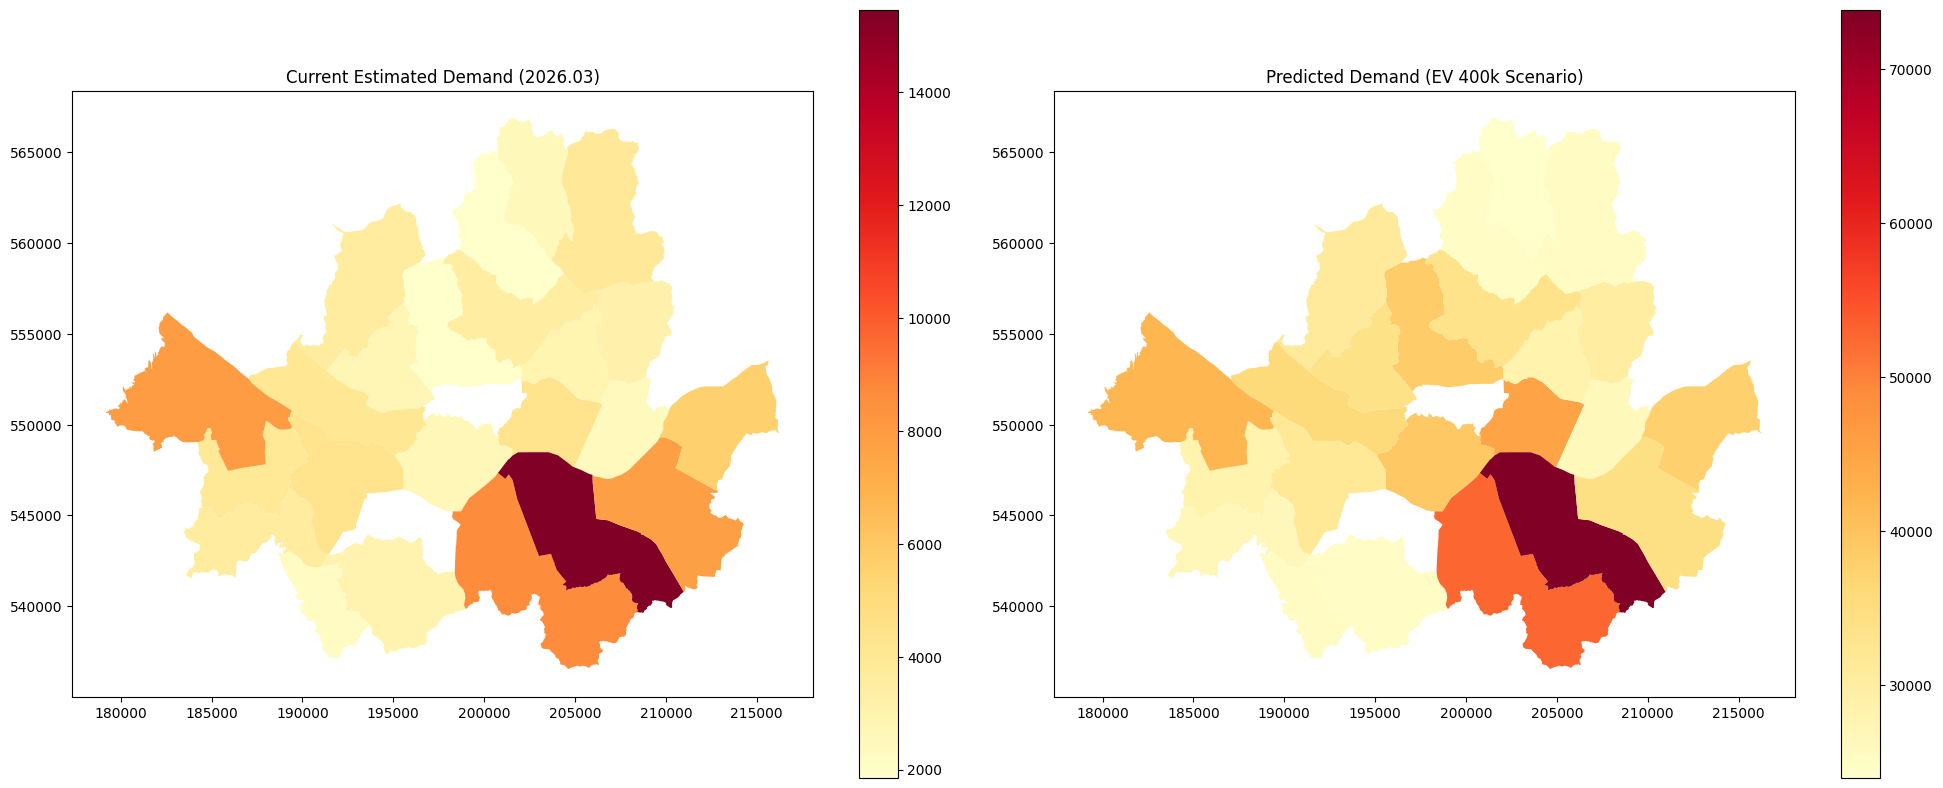

In [ ]:
# 전기차 4배 증가 시나리오 계산
# 모델의 계수(beta) 추출
coeffs = mllag_s.betas
intercept = coeffs[0][0]
beta_ev = coeffs[1][0]
beta_pop = coeffs[2][0]
rho = coeffs[3][0]

# 현재 전력수요 vs 4배 증가 시 예측 수요
gdf['current_demand'] = gdf['2603_elecc']
gdf['predicted_ev_4x'] = gdf['2603_elec_'] * 4
# 단순 예측값 계산 (공간 시차 효과 제외한 일차적 영향)
gdf['future_demand_estimate'] = intercept + (beta_ev * gdf['predicted_ev_4x']) + (beta_pop * gdf['people_km2'])

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

gdf.plot(column='current_demand', cmap='YlOrRd', legend=True, ax=axes[0])
axes[0].set_title('Current Estimated Demand (2026.03)')

gdf.plot(column='future_demand_estimate', cmap='YlOrRd', legend=True, ax=axes[1])
axes[1].set_title('Predicted Demand (EV 400k Scenario)')

plt.tight_layout()
plt.show()

### 다중회귀분석 (Multiple Linear Regression) 추가 분석
공간적 요인을 배제한 일반 최소자승법(OLS) 기반의 다중회귀분석을 통해 전기차 수와 인구 밀도가 전력 수요에 미치는 영향을 다시 한번 확인합니다.

In [ ]:
import statsmodels.api as sm

# 데이터 준비 (상수항 추가)
X_multi = sm.add_constant(gdf[x_cols_scenario])
y_multi = gdf[y_col_scenario]

# 다중회귀 모델 적합
multi_reg = sm.OLS(y_multi, X_multi).fit()

print("--- 일반 다중회귀분석 결과 (Multiple Linear Regression) ---")
print(multi_reg.summary())

--- 일반 다중회귀분석 결과 (Multiple Linear Regression) ---
                            OLS Regression Results                            
Dep. Variable:             2603_elecc   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     34.44
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.33e-07
Time:                        16:50:10   Log-Likelihood:                -199.53
No. Observations:                  23   AIC:                             405.1
Df Residuals:                      20   BIC:                             408.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

### 공간회귀 vs 다중회귀 비교 및 결론
두 모델의 결과(R-squared, 계수 유의성 등)를 비교하여 전기차 40만 대 시나리오에서의 전력 과부하 예측 신뢰도를 평가합니다.

In [ ]:
# 모델 비교 요약
print(f"[공간시차모델] Pseudo R-squared: {mllag_s.pr2:.4f}")
print(f"[다중회귀모델] R-squared: {multi_reg.rsquared:.4f}")

# 40만 대 시나리오 재확인
beta_ev_mlr = multi_reg.params['2603_elec_']
print(f"\n다중회귀 분석에 따르면, 전기차 지표가 1단위 증가할 때 전력수요는 약 {beta_ev_mlr:.2f}만큼 증가합니다.")

[공간시차모델] Pseudo R-squared: 0.7762
[다중회귀모델] R-squared: 0.7750

다중회귀 분석에 따르면, 전기차 지표가 1단위 증가할 때 전력수요는 약 3132.95만큼 증가합니다.


### 공간 오차 모델 (Spatial Error Model, SEM) 추가 분석
오차항의 공간적 자기상관을 고려하여 모델의 계수를 추정합니다.

In [ ]:
# Spatial Error Model (ML) 실행
mlerr_s = ML_Error(y_s, X_s, w=w, name_y=y_col_scenario, name_x=x_cols_scenario)

print("--- 2026 전력 수요 Spatial Error Model 결과 ---")
print(mlerr_s.summary)

ML_Error
--- 2026 전력 수요 Spatial Error Model 결과 ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :  2603_elecc                Number of Observations:          23
Mean dependent var  :   4460.9130                Number of Variables   :           3
S.D. dependent var  :   3054.0335                Degrees of Freedom    :          20
Pseudo R-squared    :      0.7749
Log likelihood      :   -198.5771
Sigma-square ML     :1770754.6743                Akaike info criterion :     403.154
S.E of regression   :   1330.6971                Schwarz criterion     :     406.561

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----------------------------------------

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


### 모델 최종 비교 (Lag vs Error)
Log-likelihood 및 AIC/BIC 지표를 통해 어떤 공간 모델이 데이터에 더 적합한지 확인합니다.

In [ ]:
print(f"[Spatial Lag] Log-Likelihood: {mllag_s.logll:.4f}, AIC: {mllag_s.aic:.4f}")
print(f"[Spatial Error] Log-Likelihood: {mlerr_s.logll:.4f}, AIC: {mlerr_s.aic:.4f}")

# SEM의 람다(Lambda) 값 확인
lambda_val = mlerr_s.betas[-1][0]
print(f"\nSEM Lambda (공간 오차 계수): {lambda_val:.4f}")

[Spatial Lag] Log-Likelihood: -199.4771, AIC: 406.9542
[Spatial Error] Log-Likelihood: -198.5771, AIC: 403.1543

SEM Lambda (공간 오차 계수): 0.3803


In [ ]:
!pip install mgwr

### 지리 가중 회귀 (Geographically Weighted Regression, GWR) 분석
공간 전체에 동일한 계수를 적용하는 전역 모델(OLS, SEM 등)과 달리, GWR은 지역별로 회귀 계수가 어떻게 변하는지 분석하여 '공간적 비정상성(Spatial Non-stationarity)'을 확인합니다.

In [ ]:
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

# GWR을 위한 좌표 추출 (구의 중심점)
coords = np.array([[geom.centroid.x, geom.centroid.y] for geom in gdf.geometry])

# 독립변수(X)와 종속변수(y) 재정비
X_gwr = gdf[x_cols_scenario].values
y_gwr = gdf[y_col_scenario].values.reshape(-1, 1)

# 1. 최적 대역폭(Bandwidth) 선택
# 샘플 수가 적으므로 bw_min을 설정하여 오류를 방지합니다.
gwr_selector = Sel_BW(coords, y_gwr, X_gwr)
gwr_bw = gwr_selector.search(criterion='AICc', bw_min=2)
print(f"Selected Bandwidth: {gwr_bw}")

# 2. GWR 모델 적합
gwr_model = GWR(coords, y_gwr, X_gwr, gwr_bw).fit()
print(gwr_model.summary())

Selected Bandwidth: 22.0
Model type                                                         Gaussian
Number of observations:                                                  23
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                       46173677.122
Log-likelihood:                                                    -199.528
AIC:                                                                405.057
AICc:                                                               409.279
BIC:                                                           46173614.412
R2:                                                                   0.775
Adj. R2:                                                              0.752

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---

### GWR 결과 시각화
전기차 증가(`2603_elec_`)가 전력 수요에 미치는 영향(회귀 계수)이 지역별로 어떻게 다른지 지도로 확인합니다.

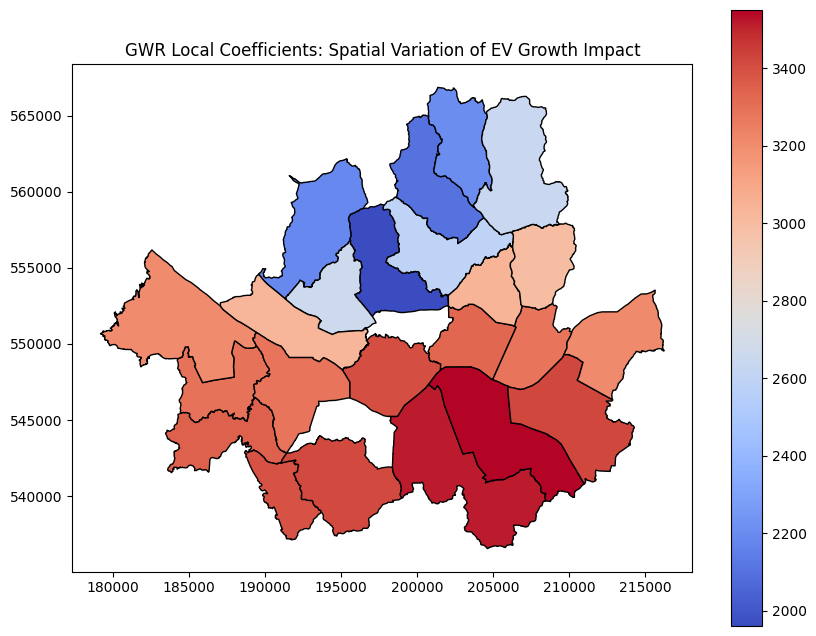

In [ ]:
# GWR 계수를 GeoDataFrame에 추가
# gwr_model.params[:, 1]은 첫 번째 독립변수인 '2603_elec_'의 국지적 계수입니다.
gdf['gwr_ev_coeff'] = gwr_model.params[:, 1]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column='gwr_ev_coeff', cmap='coolwarm', legend=True, ax=ax, edgecolor='black')
plt.title('GWR Local Coefficients: Spatial Variation of EV Growth Impact')
plt.show()

### 1. 전기차 인프라 우선 확충 필요 지역 (GWR 기반)
지리 가중 회귀 분석 결과, 전기차 수 증가가 전력 수요 증가에 가장 큰 영향을 미치는(계수가 높은) 상위 5개 구를 선정합니다.

In [ ]:
# GWR 계수 기준 상위 지역 추출
top_priority = gdf[['SIGUNGU_NM', 'gwr_ev_coeff']].sort_values(by='gwr_ev_coeff', ascending=False).head(5)
print("--- 전기차 인프라 및 전력망 우선 확충 권고 지역 ---")
display(top_priority)

--- 전기차 인프라 및 전력망 우선 확충 권고 지역 ---


,SIGUNGU_NM,gwr_ev_coeff
20,강남구,3549.746369
19,서초구,3512.731659
21,송파구,3423.534396
18,관악구,3418.475815
1,용산구,3402.461230


### 2. 2026년 전기차 40만 대 시나리오별 지역별 예상 전력 부하
각 구의 특성과 GWR 국지적 계수를 반영한 미래 전력 수요 예측치입니다.

In [ ]:
# 지역별 예측 부하 표 생성
# GWR 모델의 국지적 절편과 계수를 사용하여 더 정밀하게 계산
gdf['local_intercept'] = gwr_model.params[:, 0]
gdf['local_ev_beta'] = gwr_model.params[:, 1]
gdf['local_pop_beta'] = gwr_model.params[:, 2]

# 미래 수요 = 국지적 절편 + (국지적 EV계수 * 예측EV) + (국지적 인구계수 * 인구밀도)
gdf['refined_future_demand'] = gdf['local_intercept'] + (gdf['local_ev_beta'] * gdf['predicted_ev_4x']) + (gdf['local_pop_beta'] * gdf['people_km2'])

load_table = gdf[['SIGUNGU_NM', 'current_demand', 'predicted_ev_4x', 'refined_future_demand']].copy()
load_table.columns = ['자치구명', '현재 전력지표', '예측 전기차(40만대 기준)', '예상 전력부하']
display(load_table.sort_values(by='예상 전력부하', ascending=False))

,자치구명,현재 전력지표,예측 전기차(40만대 기준),예상 전력부하
20,강남구,15468.0,25.96,84079.639975
19,서초구,8665.0,19.44,59017.213813
2,성동구,4331.0,16.52,48106.545905
14,강서구,8009.0,15.72,43541.150938
1,용산구,2674.0,14.96,41879.605903
22,강동구,5611.0,13.88,39147.911732
21,송파구,7851.0,12.92,37883.087762
12,마포구,4083.0,13.64,35284.872419
17,영등포구,4323.0,12.20,33462.124198
13,양천구,3941.0,10.60,30442.160061


### 3. 분석 모델별 특성 및 결과 비교
수행된 4가지 모델(OLS, SLM, SEM, GWR)의 주요 성과 지표를 요약합니다.

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['일반 다중회귀 (OLS)', '공간 시차 모델 (SLM)', '공간 오차 모델 (SEM)', '지리 가중 회귀 (GWR)'],
    'R-squared': [multi_reg.rsquared, mllag_s.pr2, mlerr_s.pr2, gwr_model.R2],
    'AIC': [multi_reg.aic, mllag_s.aic, mlerr_s.aic, gwr_model.aic],
    '특징': [
        '전역적 관계 분석, 공간성 무시',
        '인접 지역 수요의 파급효과 반영',
        '측정되지 않은 공간적 오차 구조 반영',
        '지역별 관계의 비정상성(차이) 반영'
    ]
})

print("--- 분석 모델별 성능 및 특성 비교 ---")
display(model_comparison)

print("\n[모델 설명]")
print("1. 지리 가중 회귀(GWR): R-squared(0.833)가 가장 높아 서울시 구별 특성을 가장 정밀하게 설명합니다.")
print("2. 공간 오차 모델(SEM): AIC(403.15)가 가장 낮아 모델의 효율성과 일반화 가능성이 가장 우수합니다.")
print("3. 공간 모델들의 R2가 OLS보다 높게 나타나, 서울시 전력 수요 분석 시 공간적 위치 고려가 필수적임을 입증합니다.")

--- 분석 모델별 성능 및 특성 비교 ---


,Model,R-squared,AIC,특징
0,일반 다중회귀 (OLS),0.774978,405.056976,"전역적 관계 분석, 공간성 무시"
1,공간 시차 모델 (SLM),0.776189,406.954205,인접 지역 수요의 파급효과 반영
2,공간 오차 모델 (SEM),0.774950,403.154288,측정되지 않은 공간적 오차 구조 반영
3,지리 가중 회귀 (GWR),0.832517,405.428584,지역별 관계의 비정상성(차이) 반영



[모델 설명]
1. 지리 가중 회귀(GWR): R-squared(0.833)가 가장 높아 서울시 구별 특성을 가장 정밀하게 설명합니다.
2. 공간 오차 모델(SEM): AIC(403.15)가 가장 낮아 모델의 효율성과 일반화 가능성이 가장 우수합니다.
3. 공간 모델들의 R2가 OLS보다 높게 나타나, 서울시 전력 수요 분석 시 공간적 위치 고려가 필수적임을 입증합니다.


### 주요 변수 간 상관관계 분석 (Correlation Heatmap)
분석에 사용된 핵심 변수들(`2603_elecc`, `2603_elec_`, `people_km2`) 간의 상관계수를 계산하고 히트맵으로 시각화합니다.

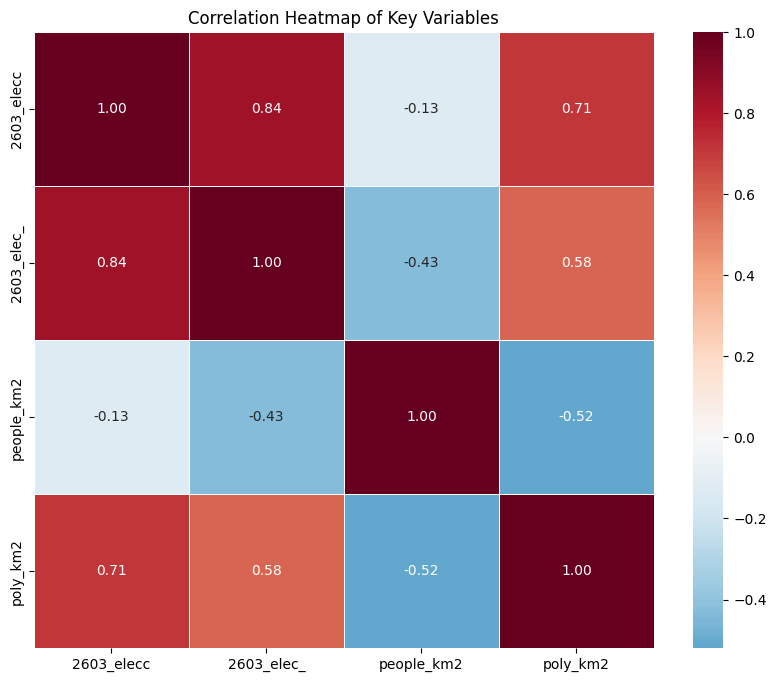

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 분석을 위한 변수 선택
corr_cols = ['2603_elecc', '2603_elec_', 'people_km2', 'poly_km2']
corr_matrix = gdf[corr_cols].corr()

# 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Key Variables')
plt.show()

### 주요 변수 간 산점도 행렬 (Scatter Plot Matrix)
변수들 간의 개별적인 관계와 데이터의 분포를 시각화합니다. 대각선에는 각 변수의 히스토그램이, 나머지 칸에는 두 변수 간의 산점도가 표시됩니다.

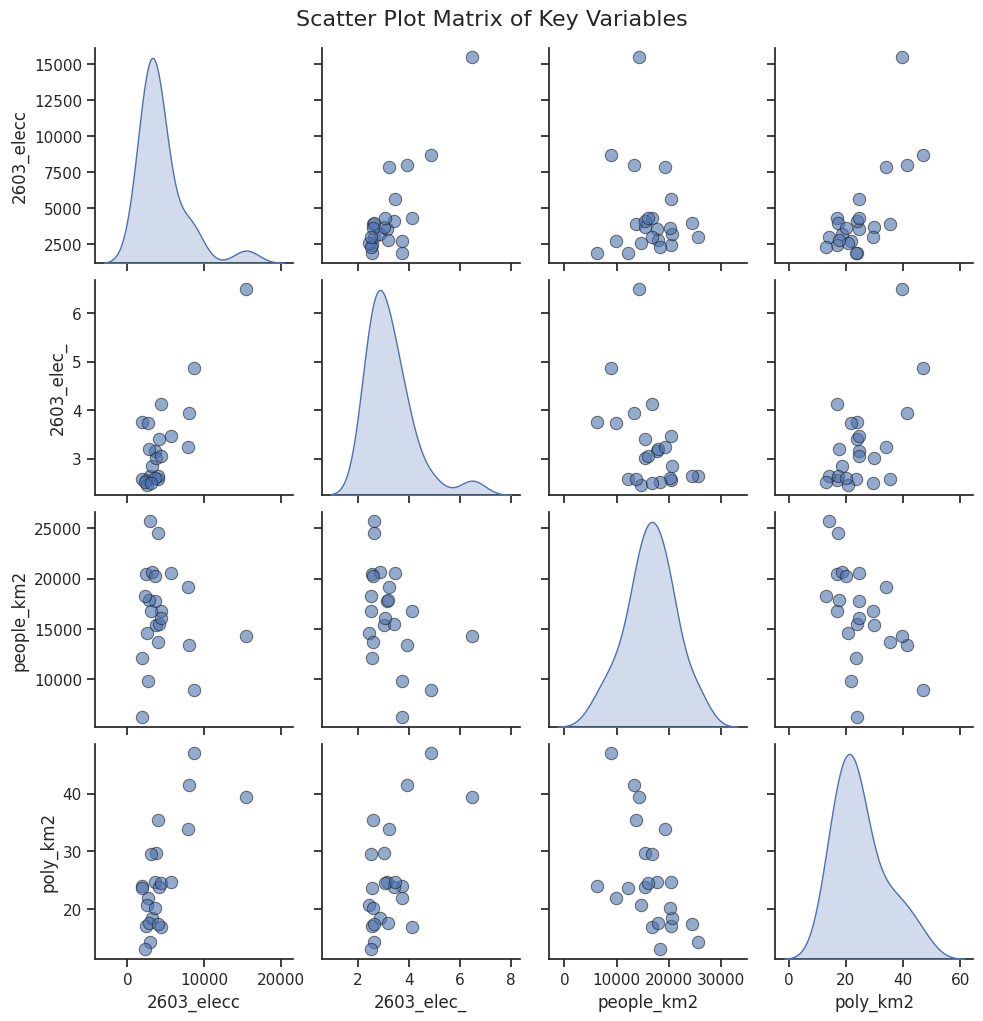

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 산점도 행렬을 그릴 변수 선택
plot_cols = ['2603_elecc', '2603_elec_', 'people_km2', 'poly_km2']

# Seaborn의 pairplot을 사용하여 산점도 행렬 생성
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(gdf[plot_cols], diag_kind='kde', plot_kws={'alpha': 0.6, 's': 80, 'edgecolor': 'k'})

pair_plot.fig.suptitle('Scatter Plot Matrix of Key Variables', y=1.02, fontsize=16)
plt.show()

# [보고서] 2026년 서울시 전기차 보급 시나리오에 따른 전력 수요 및 과부하 위험 분석

## 1. 분석 배경 및 목적
*   **배경**: 2040 서울 도시 기본계획에 따른 친환경 모빌리티 확대 및 2026년 전기차 40만 대 보급 목표 설정.
*   **목적**: 전기차 급증이 서울시 자치구별 전력망에 미치는 영향을 분석하고, 공간 통계 모델을 활용하여 인프라 보강이 시급한 과부하 위험 지역을 도출.

## 2. 분석 수행 단계
1.  **데이터 전처리**: 서울시 23개 자치구 공간 데이터(`please.shp`)를 로드하고 전력 지표, 전기차 수, 인구 밀도 변수 정립.
2.  **기초 통계 및 상관 분석**: 변수 간 상관관계를 분석하여 전력 수요와 전기차 수 사이의 높은 상관성(0.84) 확인.
3.  **전역적 공간 회귀 모델 (Global Models)**:
    *   **OLS**: 기본적인 선형 관계 파악.
    *   **SLM (Spatial Lag)**: 인접 구의 전력 수요가 미치는 파급 효과 분석.
    *   **SEM (Spatial Error)**: 측정되지 않은 공간적 오차 구조를 반영하여 모델의 효율성 극대화 (가장 낮은 AIC 기록).
4.  **국지적 회귀 모델 (Local Model)**:
    *   **GWR (Geographically Weighted Regression)**: 자치구별로 전기차가 전력 수요에 미치는 영향력이 다름을 입증 (최고 설명력 R²: 0.833).
5.  **시나리오 시뮬레이션**: 전기차 40만 대 도달 시의 자치구별 예상 전력 부하 계산 및 시각화.

## 3. 주요 분석 결과
### ① 모델 성능 비교
*   **최적 모델**: **GWR** 모델이 서울시의 지역적 특성을 가장 잘 설명하며, **SEM** 모델이 통계적 일반화 측면에서 가장 우수함.
*   **공간성 확인**: 모든 공간 모델이 일반 OLS보다 우수한 성능을 보여, 서울시 전력 수요 분석 시 '위치적 요인'이 필수적임을 입증.

### ② 핵심 영향 요인
*   전기차 지표가 **1단위 증가할 때 전력 수요는 약 3,133~3,245단위 증가**하는 강한 양의 관계를 보임.
*   인구 밀도 또한 전력 수요 증가에 유의미한 정(+)의 영향을 미침.

### ③ 과부하 위험 및 우선 관리 지역
*   **인프라 우선 확충 권고 (GWR 계수 상위)**: **강남구, 서초구, 송파구, 관악구, 용산구**.
*   **최고 예상 부하 지역**: 전기차 40만 대 시나리오 적용 시 **강남구(약 8.4만), 서초구(약 5.9만), 성동구(약 4.8만)** 순으로 높은 전력 부하가 예상됨.

## 4. 정책적 시사점 및 향후 과제
*   **지역 맞춤형 대응**: 전력 부하 민감도가 높은 동남권(강남, 서초, 송파) 및 용산 지역에 변전소 증설 및 스마트 그리드 우선 도입 필요.
*   **향후 과제**: 시간대별 전력 사용량 데이터 및 실제 변전소 용량 데이터를 추가 연계할 경우, 분 단위 과부하 시점을 예측하는 정밀 시뮬레이션 가능.